## Device Setup

In [1]:
import os, socket, subprocess, torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [2]:
print('hostname:', socket.gethostname())
print('SLURM_JOB_ID:', os.getenv('SLURM_JOB_ID'))
print('SLURM_NODELIST:', os.getenv('SLURM_NODELIST'))
print('torch:', torch.__version__)
print('torch.version.cuda:', torch.version.cuda)
print('torch.cuda.is_available():', torch.cuda.is_available())
print('torch.cuda.device_count():', torch.cuda.device_count())
print(subprocess.getoutput('nvidia-smi -L'))

hostname: gh092.hsn.cm.delta.internal.ncsa.edu
SLURM_JOB_ID: 2246167
SLURM_NODELIST: gh092
torch: 2.11.0+cu126
torch.version.cuda: 12.6
torch.cuda.is_available(): True
torch.cuda.device_count(): 1
GPU 0: NVIDIA GH200 120GB (UUID: GPU-ce16c13d-e984-6827-950a-ef7798f40789)


# MP 5: Diffusion Transformers

*Created by Jay Mahajan & Ozgur Kara (Spring 2026 CS 444 TAs)*

You will be implementing a custom Diffusion Transformer. Your goal is to implement a transformer (Part A) and then use it to generate handwritten digits (Part B).

Files that need to be edited: ```DiT.py```

In [ ]:
!pip install torch torchvision matplotlib tqdm einops torchmetrics[image] torch-fidelity diffusers


In [3]:
# Run only on Colab
import os
try:
  from google.colab import drive
  drive.mount('/content/drive/')
  os.chdir('/content/drive/MyDrive/<YOUR FOLDER>')
except:
  print("Not Running on Colab")


Not Running on Colab


## Part A: Implementing the transformer

You need to implement the transformer in ```DiT.py```. You will need to follow the instructions in the website.

For each sub part, you can test if it works by running ```python tests.py```. **You must pass all tests in order to get full credit!**

In [5]:
!python tests.py

..........
----------------------------------------------------------------------
Ran 10 tests in 3.712s

OK


## Part B: Training with DDPM

Once you have the transformer built, you will train it with DDPM.

In [3]:
import torch
from DiT import DiT
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from torchvision.utils import make_grid
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
from torchmetrics.image.fid import FrechetInceptionDistance
%matplotlib inline

# Use cuSolver instead of MAGMA for GPU linalg (required for FID on this cluster)
torch.backends.cuda.preferred_linalg_library("cusolver")

/u/akoric/envs/cs444-mp4/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[W505 10:36:55.878747824 Context.cpp:444] Warning: torch.backends.cuda.preferred_linalg_library is an experimental feature. If you see any error or unexpected behavior when this flag is set please file an issue on GitHub. (function operator())


<_LinalgBackend.Cusolver: 1>

In [4]:
### Set Hyperparameters, do not change these, unless you are doing extra credit
res = 28
patch_size = 4
channels = 1
heads = 8
hidden_dim = 256
num_patch = (res // patch_size) ** 2
ff_dim = 1024
time_emb_dim = 256
num_blocks = 5
num_timesteps = 300

beta_0 = 0.0001
beta_t = 0.02

batch_size = 64
num_epoch = 100
lr=4e-4

In [5]:
### Helper function to show images
def show_images(imgs):
    batch_min = imgs.view(imgs.size(0), -1).min(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    batch_max = imgs.view(imgs.size(0), -1).max(dim=1, keepdim=True)[0].view(-1, 1, 1, 1)
    imgs = (imgs - batch_min) / (batch_max - batch_min + 1e-6)
    imgs = imgs.detach().cpu()
    grid = make_grid(imgs, nrow=5)
    plt.axis('off')
    plt.imshow(grid.permute(1, 2, 0))
    plt.show()

In [11]:
class Diffusion:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device) # (batch_size, channels, res, res)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint.pt')

            if e % 10 == 0:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # pure gaussian noise, same shape as target image: (batch_size, channels, res, res)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # estimate clean image x0 from prediction
                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device) # (num_samples,)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z  = torch.randn_like(xt) # N(0, Identity (I))
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    z  = torch.zeros_like(xt) # no noise at final step
                    xt = mean

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 → RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.13649652807760848
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 238.7449951171875


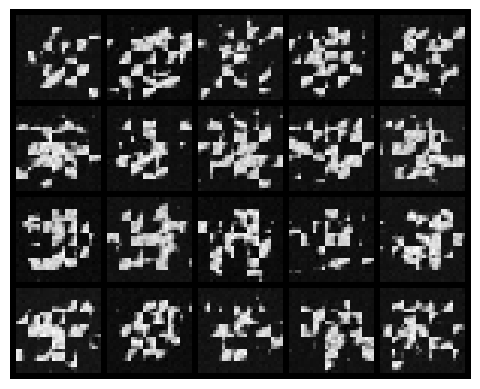

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.82it/s]


Avg Loss: 0.08131774269076171


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


Avg Loss: 0.06967763630137133


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.70it/s]


...

Avg Loss: 0.0483321387654365


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.18it/s]


Avg Loss: 0.04737363309303581


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.33it/s]


Avg Loss: 0.04677601745610298
Epoch: 11
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 59.077171325683594


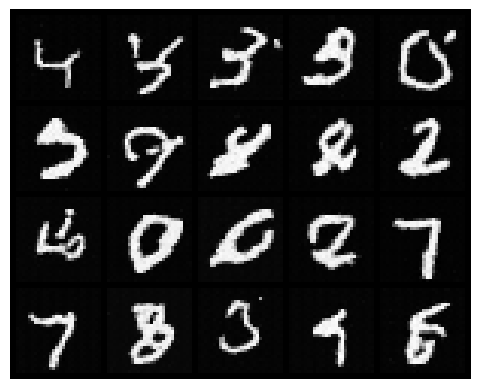

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:00<00:00, 15.46it/s]


Avg Loss: 0.046076219846635486


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.25it/s]


Avg Loss: 0.04597304500480578


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.84it/s]


...

Avg Loss: 0.04410155334158429


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.89it/s]


Avg Loss: 0.04383684903867781


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.04357779428942689
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 48.11210632324219


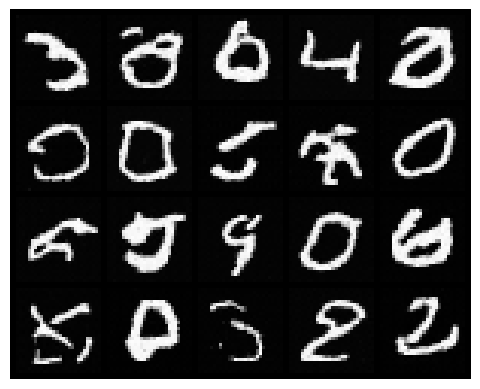

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.29it/s]


Avg Loss: 0.043351431222342605


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.19it/s]


Avg Loss: 0.04306511244555907


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.95it/s]


...

Avg Loss: 0.0425472020336401


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.77it/s]


Avg Loss: 0.04229033077314401


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.68it/s]


Avg Loss: 0.04208132914547473
Epoch: 31
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 36.36958694458008


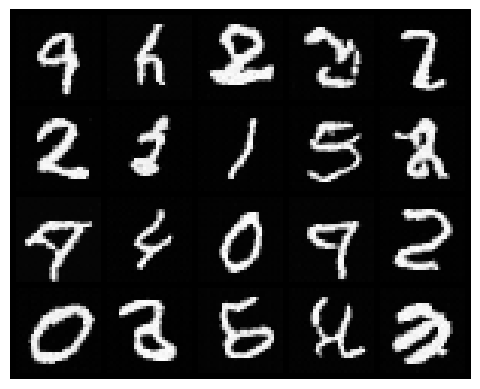

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.55it/s]


Avg Loss: 0.04205396358988115


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.04207741908395468


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:05<00:00, 14.43it/s]


...

Avg Loss: 0.0415820744353285


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.60it/s]


Avg Loss: 0.041351313128876785


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.56it/s]


Avg Loss: 0.041274844573489004
Epoch: 41
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 38.92129135131836


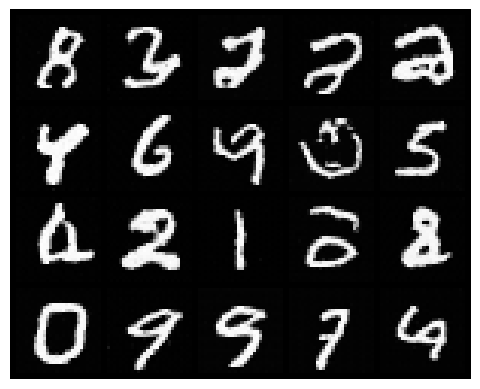

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.84it/s]


Avg Loss: 0.041371028592337426


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.33it/s]


Avg Loss: 0.04127233570167568


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.85it/s]


...

Avg Loss: 0.041137699371398384


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.040998775476236336


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.00it/s]


Avg Loss: 0.041074667348345716
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 36.81208419799805


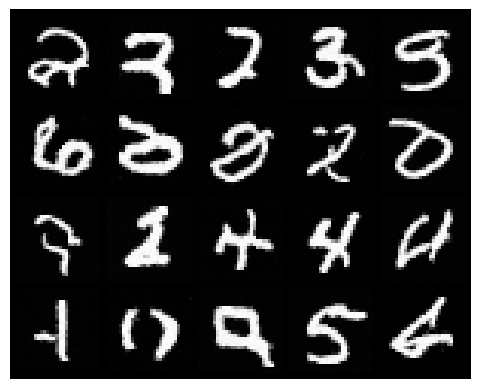

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.94it/s]


Avg Loss: 0.04093569248064812


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.92it/s]


Avg Loss: 0.04097230936577325


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.85it/s]


...

Avg Loss: 0.04079391984050589


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


Avg Loss: 0.04073316297694437


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.86it/s]


Avg Loss: 0.04060718768250459
Epoch: 61
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 37.3053092956543


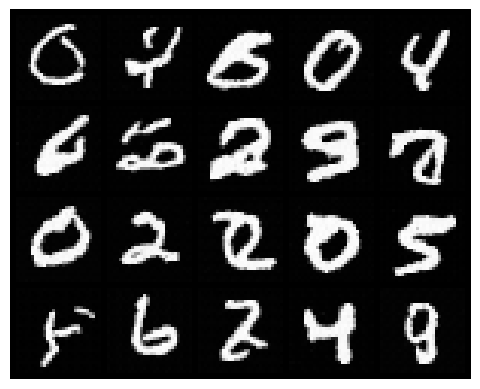

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.89it/s]


Avg Loss: 0.04048462087379844


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.93it/s]


Avg Loss: 0.04042551866663036


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


...

Avg Loss: 0.040298216070717714


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04037482439002185


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.04015397883729258
Epoch: 71
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 37.58024978637695


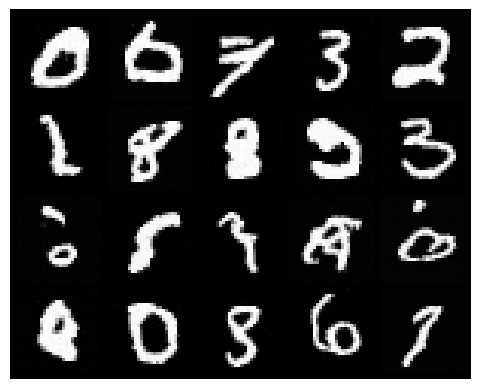

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.22it/s]


Avg Loss: 0.03988894727279637


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.86it/s]


Avg Loss: 0.0402502487900097


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.05it/s]


...

Avg Loss: 0.03999062759011412


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.83it/s]


Avg Loss: 0.039920581971356735


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.08it/s]


Avg Loss: 0.0398606364327326
Epoch: 81
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 33.2996940612793


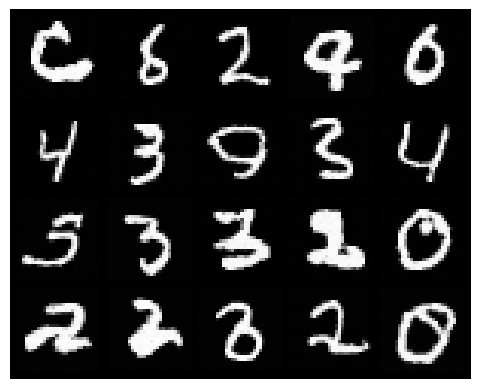

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.03it/s]


Avg Loss: 0.03986564993477071


 91%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌                | 851/938 [00:56<00:05, 15.02it/s]


KeyboardInterrupt: 

In [ ]:
d = Diffusion()

d.train()

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 82


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.94it/s]


Avg Loss: 0.039672424975059815


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.11it/s]


Avg Loss: 0.039863672627727866


...

Avg Loss: 0.03954051128590603


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.45it/s]


Avg Loss: 0.03957681538366369


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.05it/s]


Avg Loss: 0.03982348371146203
Epoch: 91
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 38.900962829589844


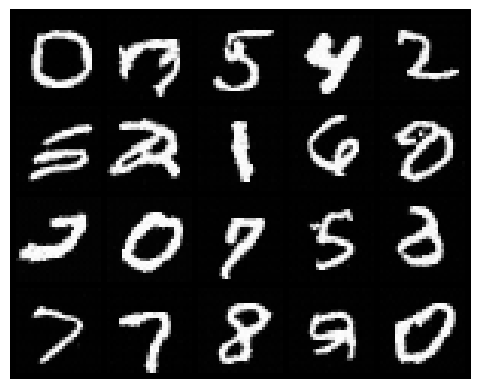

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:05<00:00, 14.30it/s]


Avg Loss: 0.039589885066249476


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.10it/s]


Avg Loss: 0.03996272381943172


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.07it/s]


...

Avg Loss: 0.039346499839174084


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:06<00:00, 14.15it/s]


Avg Loss: 0.03940286389045687


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:07<00:00, 13.97it/s]


Avg Loss: 0.03958335052381383
Final Epoch:


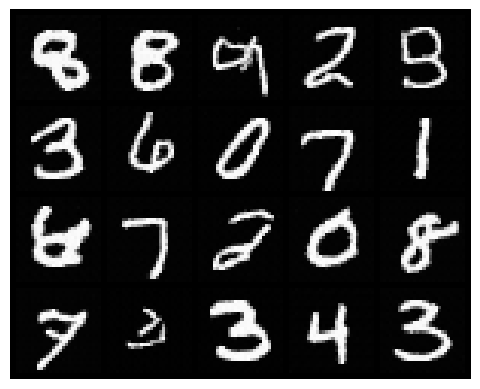

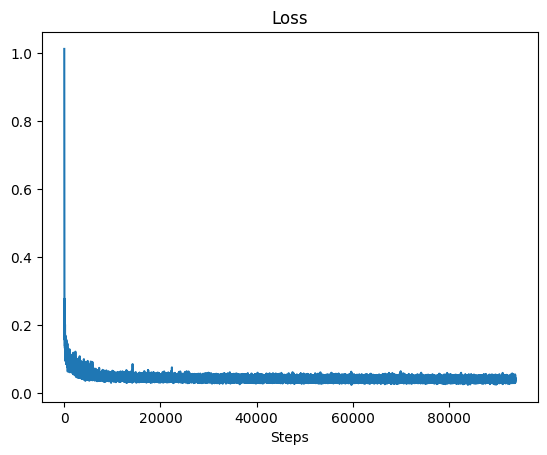

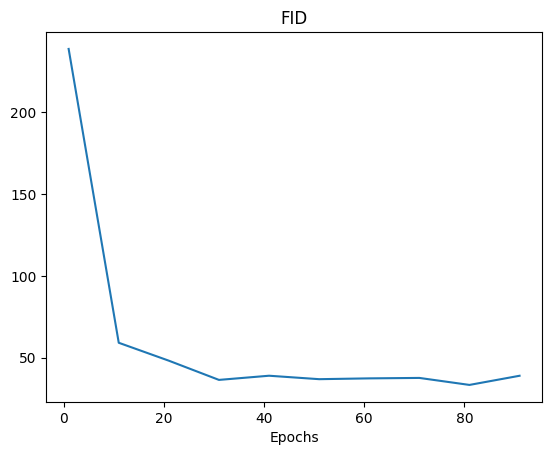

In [7]:
d = Diffusion()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

In [13]:
d = Diffusion()
d.load_checkpoint('checkpoints/checkpoint.pt')
fid = d.compute_fid()
print("Final FID:", fid)

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Final FID: 31.52375602722168


## Extra Credit: Complete any extra credit here

## Latent Diffusion Model

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from diffusers import AutoencoderKL
import torchvision.transforms as transforms
from torchvision.datasets import CelebA
import torch
import torch.nn as nn

# Load the VAE
vae = AutoencoderKL.from_pretrained("stabilityai/sdxl-vae").to(device)
vae.eval()

# freeze VAE weights
for p in vae.parameters():
    p.requires_grad = False


In [32]:
VAE_SCALE = 0.13025  # SDXL-VAE scaling factor, from Hugging Face

@torch.no_grad()
def encode(x):
    # x: (B, 3, 64, 64) normalized to [-1, 1]
    posterior = vae.encode(x).latent_dist
    z = posterior.sample() * VAE_SCALE
    # z: (B, 4, 8, 8)
    return z

@torch.no_grad()
def decode(z):
    # z: (B, 4, 8, 8)
    z = z / VAE_SCALE
    x = vae.decode(z).sample
    # x: (B, 3, 64, 64)
    return x

In [ ]:
res = 8 # latent spatial size (64 / 8)
patch_size = 2 # patch size in latent space
channels = 4 # latent channels
heads = 8
hidden_dim = 256
num_patch = (res // patch_size) ** 2  # = 16
ff_dim = 1024
time_emb_dim = 256
num_blocks = 5
num_timesteps = 300
beta_0 = 0.0001
beta_t = 0.02
batch_size = 64
num_epoch = 100
lr = 4e-4

In [34]:
from torch.utils.data import Dataset
from PIL import Image
import os

class CelebADataset(Dataset):
    """Reads directly from img_align_celeba/ folder (Kaggle download)."""
    def __init__(self, root, transform=None):
        self.img_dir = os.path.join(root, 'img_align_celeba', 'img_align_celeba')
        self.transform = transform
        self.imgs = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0  # dummy label to match CelebA interface


In [ ]:
class LatentDiffusion:

    def __init__(self):

        #[DiT-VAE] Resize to 64 x 64 pixel space (not 28x28 MNIST size)
        # [DiT-VAE] CenterCrop make a sq image after resize
        # [DiT-VAE] 3-channel norma instead of single: CelebA is RGB(3)not grayscale(1)
        trans = transforms.Compose([
            transforms.Resize(64),
            transforms.CenterCrop(64),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        # [DiT-VAE] CelebA (RGB faces) instead of MNIST (grayscale digits)
        self.dataset = CelebADataset(root='./data/celeba', transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)

        # [DiT-VAE] num_channels=channels is now 4 (latent channels) instead of 1 (MNIST grayscale)
        #[DiT-VAE] num_patches=num_patch is now 16 (8x8 latent / patch_size=2)^2 instead of 49
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)

        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_VAE.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                # get clean pixel image x0: (B, 3, 64, 64)
                imgs = imgs.to(self.device)

                # [DiT-VAE] encode pixel images to z space
                # VAE downsamples 64x64x3 -> 8x8x4; diffusion runs entirely in latent space
                with torch.no_grad():
                    z = encode(imgs)   # (B, 4, 8, 8)

                # sample a random timestep t
                # [DiT-VAE] z.shape[0] instead of imgs.shape[0] 
                # same batch size is the same but z is the target instead of img
                t = torch.randint(0, num_timesteps, (z.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(z)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * z + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_VAE.pt')

            if e % 10 == 0:
                print("Epoch:", e + 1)

                images = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(images)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # [DiT-VAE] noise starts in z space (channels=4, res=8) instead of pixel space
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z  = torch.randn_like(xt)
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    xt = mean

            # [DiT-VAE] decode denoised latents back to pixel images: (B, 4, 8, 8) -> (B, 3, 64, 64)
            pixel_imgs = decode(xt)

        return pixel_imgs


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        # [DiT-VAE]no channel repeat: decoded VAE output is already RGB (3 channels)
        #[DiT-VAE] input is 64x64, still resize to 75x75 for InceptionV3
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        # [DiT-VAE] use training_dataloader (batched) instead of dataset (unbatched single items)
        # fid.update() requires (B, C, H, W) shape; iterating dataset directly gives (C, H, W)
        for imgs, _ in self.training_dataloader:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [08:26<00:00,  6.26it/s]


Avg Loss: 0.35354208066560616
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 213.0984649658203


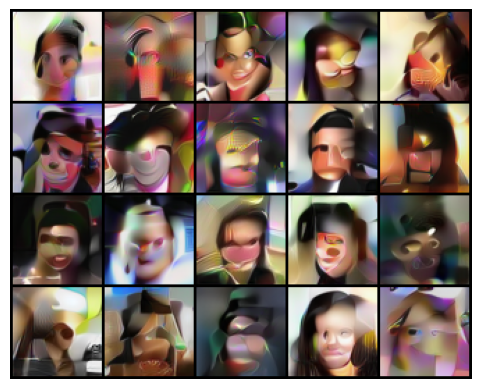

 23%|████████████████████████▏                                                                                | 729/3166 [01:31<05:04,  8.01it/s]


KeyboardInterrupt: 

In [37]:
ld = LatentDiffusion()
ld.train()


## Finished training as batch, full code in train_latent_diffusion.py

## Extra Credit: RoPE
Implement RoPE instead of the fixed positional embeddings.

Defult hyperparameters

In [6]:
class DiffusionRoPE:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels,
            use_rope=True # set to true to test
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_rope.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device) # (batch_size, channels, res, res)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_rope.pt')

            if e + 1 in {1, 21, 51, 100}:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # pure gaussian noise, same shape as target image: (batch_size, channels, res, res)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # estimate clean image x0 from prediction
                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device) # (num_samples,)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z  = torch.randn_like(xt) # N(0, Identity (I))
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    z  = torch.zeros_like(xt) # no noise at final step
                    xt = mean

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 → RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:15<00:00, 12.38it/s]


Avg Loss: 0.12273918728091951
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 176.78993225097656


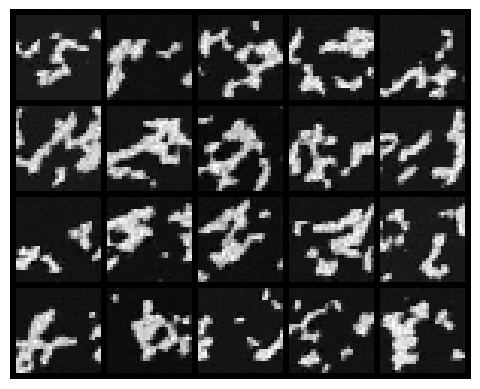

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:15<00:00, 12.49it/s]


Avg Loss: 0.06575161310782565


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:15<00:00, 12.43it/s]


Avg Loss: 0.05904081512663537


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:14<00:00, 12.57it/s]


...

Avg Loss: 0.04427648145459227


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.31it/s]


Avg Loss: 0.043974966873158654


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.27it/s]


Avg Loss: 0.04378252362868171
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 44.09507751464844


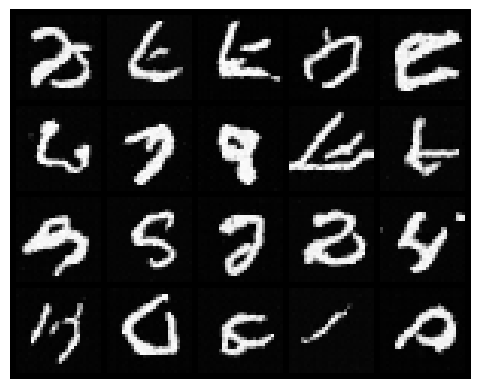

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.23it/s]


Avg Loss: 0.04353819562515407


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.24it/s]


Avg Loss: 0.04356913734227419


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:17<00:00, 12.17it/s]


...

Avg Loss: 0.04114875008167425


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:15<00:00, 12.47it/s]


Avg Loss: 0.04110805294526094


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.31it/s]


Avg Loss: 0.04118180893925525
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 35.1961555480957


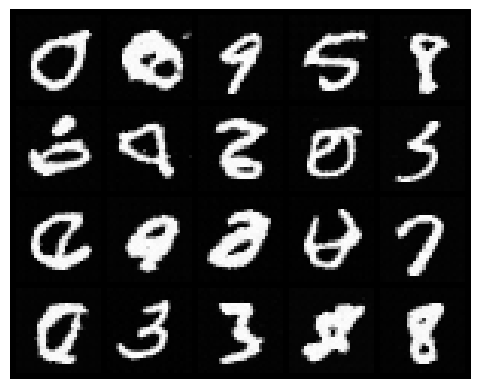

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:15<00:00, 12.48it/s]


Avg Loss: 0.041018916345608517


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:14<00:00, 12.61it/s]


Avg Loss: 0.04071688320019098


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:14<00:00, 12.65it/s]


...

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:17<00:00, 12.05it/s]


Avg Loss: 0.039580612620120366


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:16<00:00, 12.29it/s]


Avg Loss: 0.0397962005094075


 32%|███████████████████████████████████████████████████████                                                                                                                    | 302/938 [00:24<00:52, 12.02it/s]

In [ ]:
d = DiffusionRoPE()
d.train()


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 87


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:20<00:00, 11.72it/s]


Avg Loss: 0.03975572121311734


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:19<00:00, 11.75it/s]


Avg Loss: 0.039787614839211075


...

Avg Loss: 0.03949933409341363


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:20<00:00, 11.64it/s]


Avg Loss: 0.03987171800771375


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:19<00:00, 11.77it/s]


Avg Loss: 0.039633836001475485
Epoch: 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 32.998958587646484


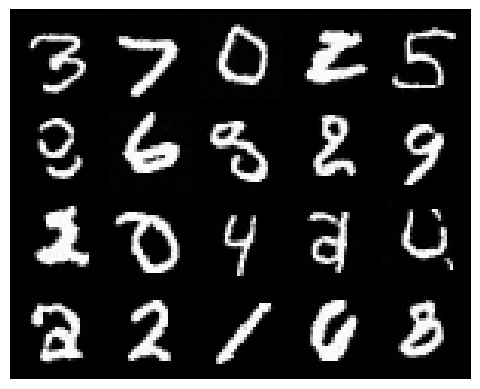

Final Epoch:


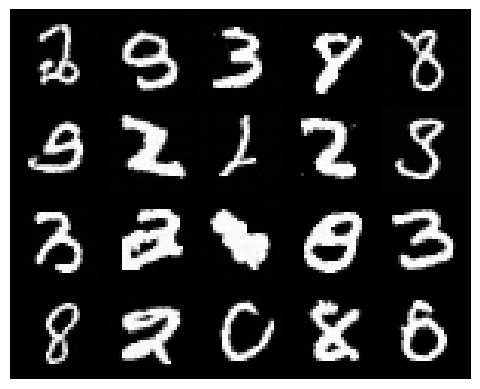

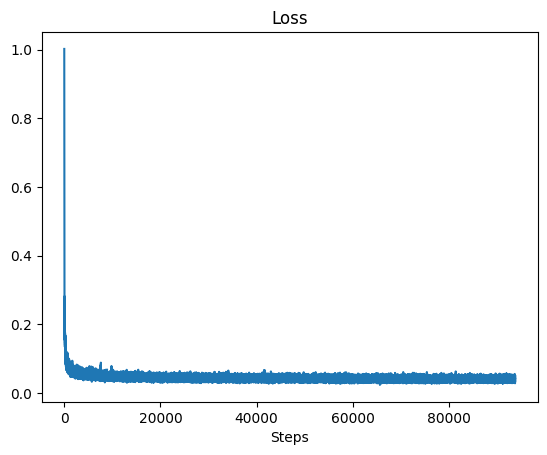

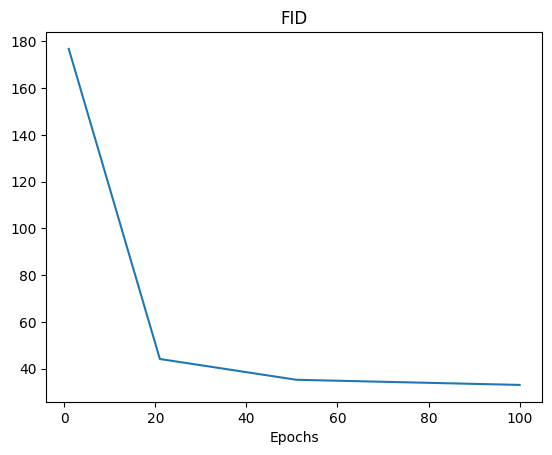

In [8]:
d = DiffusionRoPE()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint_rope.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

## Extra Credit: Positional Embedding
Train using a learned positional embedding. This should be a simple nn.Parameter that requires gradients. Display your first epoch, epoch 21, epoch 51 and the final result. Compare the results with the fixed positional embeddings.

Original pos encoding commented out, and the learned pos encoding activated.

Defult hyperparameters

In [ ]:
class DiffusionLearnedPE:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_learned_PE.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device) # (batch_size, channels, res, res)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_learned_PE.pt')
 
            if e + 1 in {1, 21, 51, 100}:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # pure gaussian noise, same shape as target image: (batch_size, channels, res, res)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # estimate clean image x0 from prediction
                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device) # (num_samples,)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z  = torch.randn_like(xt) # N(0, Identity (I))
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    z  = torch.zeros_like(xt) # no noise at final step
                    xt = mean

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 → RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.15466792811589963
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 229.09136962890625


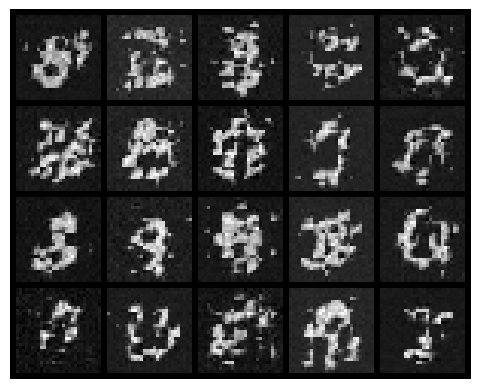

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.01it/s]


Avg Loss: 0.0812436548202658


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.93it/s]


Avg Loss: 0.06920794305850321


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.99it/s]


...

Avg Loss: 0.04729732014794848


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04724309811277239


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.04679953834331874
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 44.295997619628906


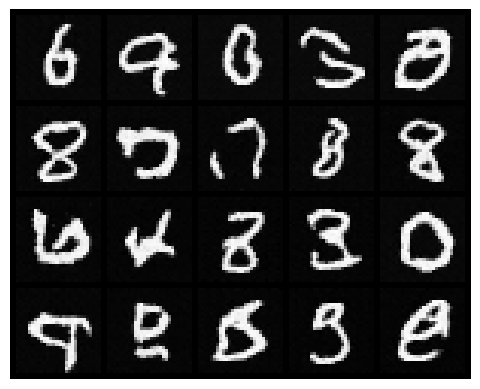

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.92it/s]


Avg Loss: 0.04606079959324492


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:00<00:00, 15.58it/s]


Avg Loss: 0.046032764295588675


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.08it/s]


...

Avg Loss: 0.042767788853440715


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.04it/s]


Avg Loss: 0.04246535937963074


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.01it/s]


Avg Loss: 0.04249569614217289
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 41.891170501708984


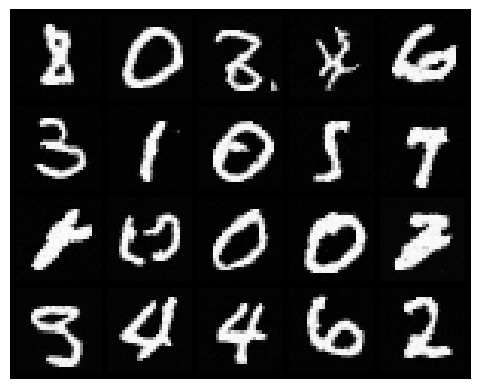

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.82it/s]


Avg Loss: 0.04229812577231797


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.04224194948082921


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.02it/s]


...

Avg Loss: 0.04029539524357138


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.00it/s]


Avg Loss: 0.04042266759830815


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.02it/s]


Avg Loss: 0.04053347284343642
Epoch: 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 31.64649200439453


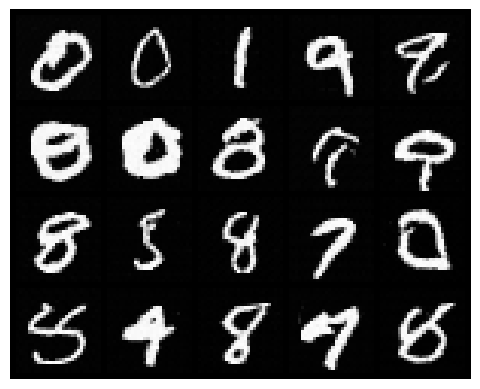

Final Epoch:


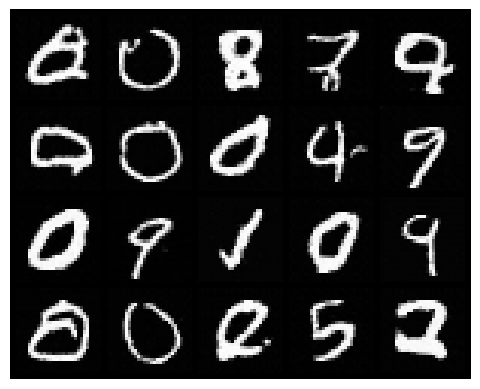

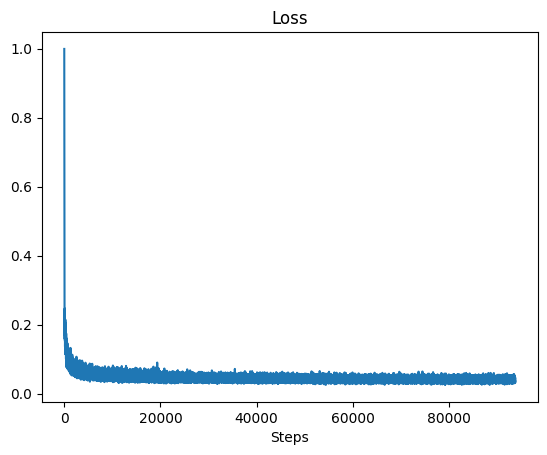

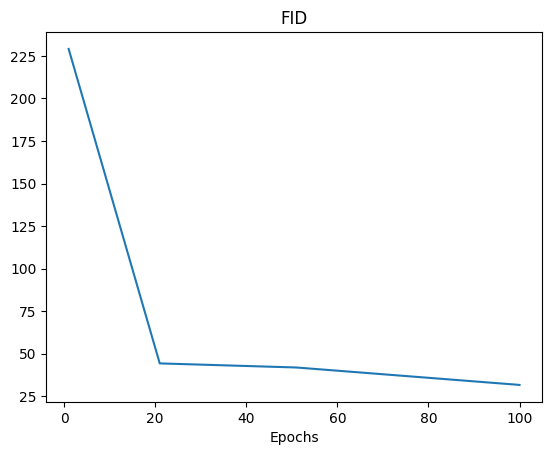

In [7]:
d = DiffusionLearnedPE()
d.train()

## Extra Credit: 
Implement DDIM to speed up inference.

Defult hyperparameters

In [7]:
ddim_steps = 50

In [12]:
class DiffusionDDIM:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_DDIM.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device) # (batch_size, channels, res, res)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)

                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_DDIM.pt')
 
            if e + 1 in {1, 21, 51, 100}:
                print("Epoch:", e + 1)
                imgs = self.run_inference_ddim()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference_ddim()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference_ddim(self, num_samples=20, ddim_steps=50):
        self.model.eval()
        with torch.no_grad():
            # Select 50 evenly-spaced steps from the 300-step training schedule
            timesteps = torch.linspace(0, num_timesteps - 1, ddim_steps).long().flip(0).to(self.device)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for i, t in enumerate(timesteps):
                alpha_bar_t = self.alpha_bars[t]
                if i + 1 < len(timesteps):
                    t_prev = timesteps[i + 1]
                    alpha_bar_t_prev = self.alpha_bars[t_prev]
                else:
                    alpha_bar_t_prev = torch.tensor(1.0, device=self.device)

                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device)
                eps = self.model(xt, t_tensor)
                x0_hat = (xt - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)
                xt = torch.sqrt(alpha_bar_t_prev) * x0_hat + torch.sqrt(1 - alpha_bar_t_prev) * eps

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 → RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference_ddim(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.71it/s]


Avg Loss: 0.15470379067541185
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 318.42742919921875


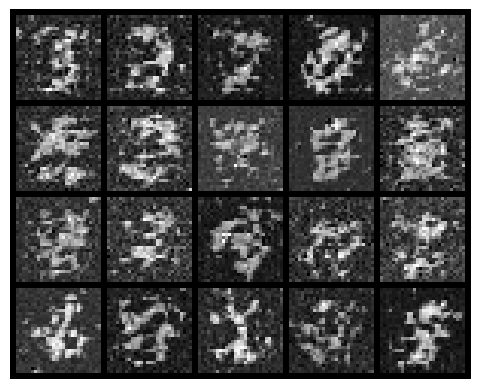

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.94it/s]


Avg Loss: 0.08262793533106856


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:00<00:00, 15.59it/s]


Avg Loss: 0.06845929057819884


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.80it/s]


...

Avg Loss: 0.047208513921575504


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.87it/s]


Avg Loss: 0.0471076644869692


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.94it/s]


Avg Loss: 0.046515253660425956
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 93.6526107788086


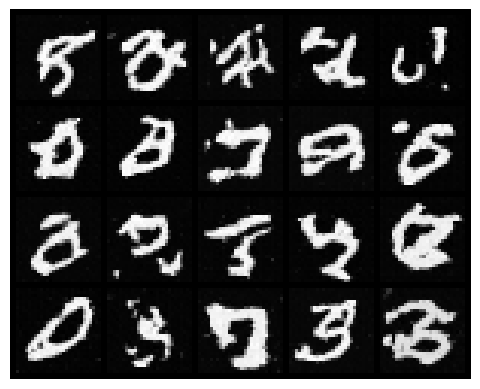

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04664647771216341


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04644845567270319


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.01it/s]


...

Avg Loss: 0.042644988640205564


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.05it/s]


Avg Loss: 0.04273219800778607


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.96it/s]


Avg Loss: 0.04221230695472915
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 61.692745208740234


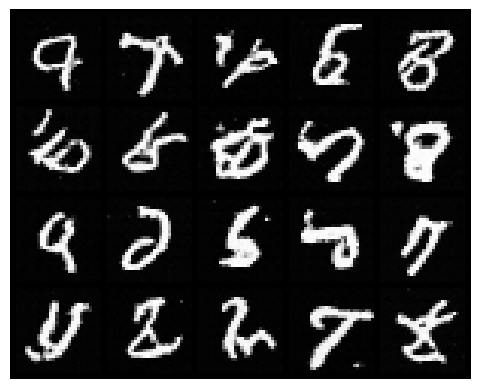

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.04239648066635834


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:05<00:00, 14.43it/s]


Avg Loss: 0.04205464569927215


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.46it/s]


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.81it/s]


Avg Loss: 0.040463999910617686


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.67it/s]


Avg Loss: 0.04019810918813893


 19%|████████████████████████████████▊                                                                                                                                                | 174/938 [00:11<00:51, 14.93it/s]

In [ ]:
d = DiffusionDDIM()
d.train()

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 99


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:10<00:00, 13.22it/s]


Avg Loss: 0.04014928176649598
Epoch: 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 50.668174743652344


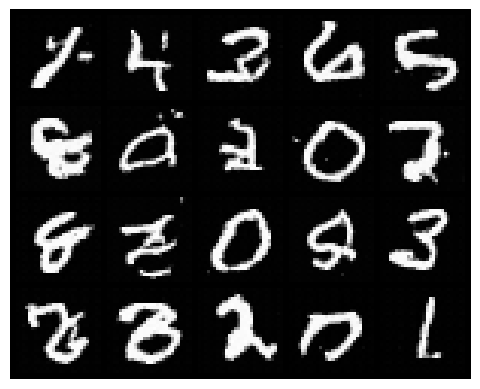

Final Epoch:


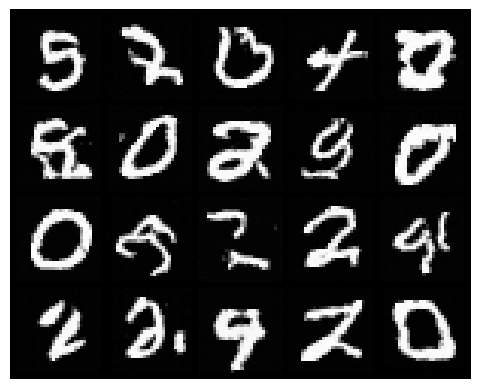

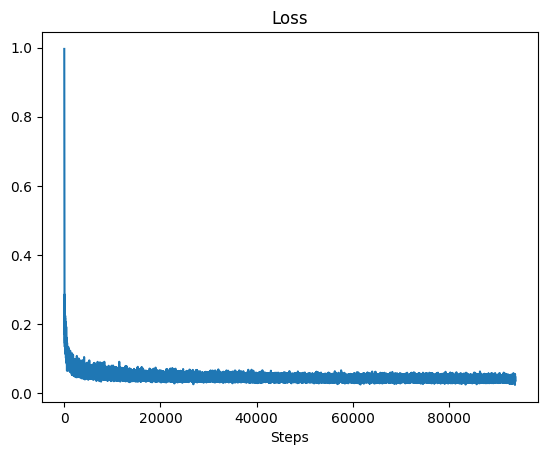

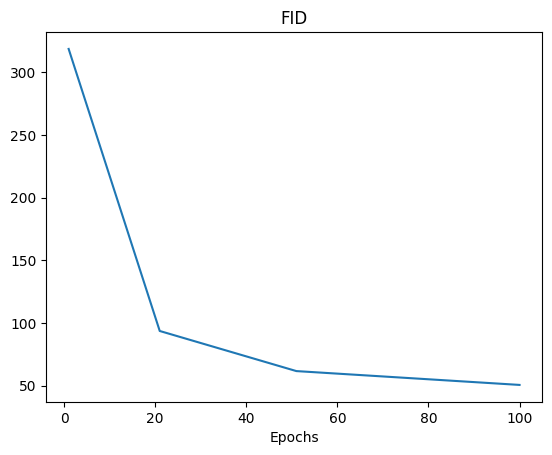

In [9]:
d = DiffusionDDIM()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint_DDIM.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
DDIM 50 steps:  0.85s
DDPM 300 steps: 4.98s


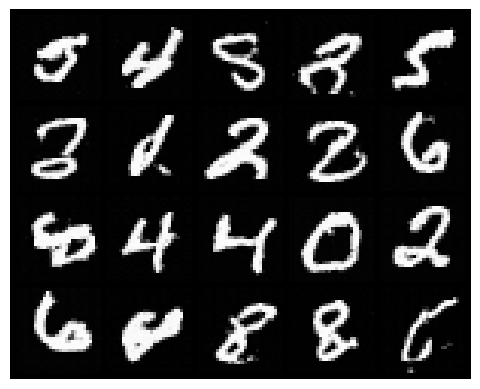

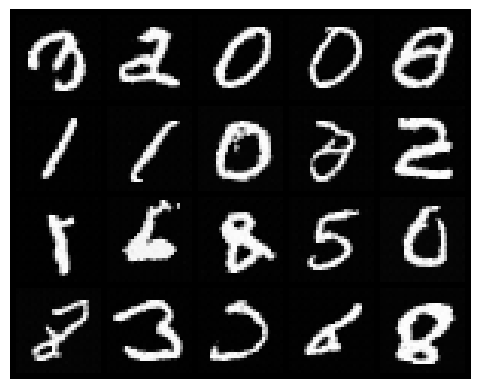

In [12]:
import time

# DDIM model (300-step schedule, 50-step inference)
ddim = DiffusionDDIM()
ddim.load_checkpoint('checkpoints/checkpoint_DDIM.pt')

# DDPM model (300-step schedule, 300-step inference)
d = Diffusion()
d.load_checkpoint('checkpoints/checkpoint.pt')

start = time.time()
imgs_ddim = ddim.run_inference_ddim(num_samples=20, ddim_steps=50)
print(f"DDIM 50 steps:  {time.time() - start:.2f}s")

start = time.time()
imgs_ddpm = d.run_inference(num_samples=20)
print(f"DDPM 300 steps: {time.time() - start:.2f}s")

show_images(imgs_ddim)
show_images(imgs_ddpm)


## Extra Credit: Train DDPM uisng CelebA

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from diffusers import AutoencoderKL
import torchvision.transforms as transforms
from torchvision.datasets import CelebA
import torch
import torch.nn as nn

from torch.utils.data import Dataset
from PIL import Image
import os


# Dataset  ===================================================================================
class CelebADataset(Dataset):
    """Reads directly from img_align_celeba/ folder (Kaggle download)."""
    def __init__(self, root, transform=None):
        self.img_dir = os.path.join(root, 'img_align_celeba', 'img_align_celeba')
        self.transform = transform
        self.imgs = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.imgs[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0

In [ ]:
res = 64 # images are 64 x 64
patch_size = 4
channels = 3 # R,G,B
heads = 8
hidden_dim = 256
num_patch = (res // patch_size) ** 2  # = 256
ff_dim = 1024
time_emb_dim = 256
num_blocks = 5
num_timesteps = 300
beta_0 = 0.0001
beta_t = 0.02
batch_size = 64
num_epoch = 15
lr = 4e-4

In [8]:
class DiffusionCelebA:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(64),
            transforms.CenterCrop(64),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        self.dataset = CelebADataset(root='./data/celeba', transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        self.betas = torch.linspace(beta_0, beta_t, num_timesteps).to(self.device)
        self.alphas = (1 - self.betas).to(self.device)

        # Alpha bar (cumulative product)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(self.device)

        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels
        ).to(self.device)

        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)
        
        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_CelebA.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                ### TODO: Implement the training process in DDPM Algorithm 1
                # get clean image x0
                imgs = imgs.to(self.device)

                # sample a random timestep t
                t = torch.randint(0, num_timesteps, (imgs.shape[0],), device=self.device)
                
                ## Create a random noise vector
                eps = torch.randn_like(imgs)

                ## Run the diffusion process
                ab = self.alpha_bars[t].view(-1, 1, 1, 1)
                xt_noise = torch.sqrt(ab) * imgs + torch.sqrt(1 - ab) * eps

                # Transformer predicts the noise
                noise_pred = self.model(xt_noise, t)
                
                # Compute the loss and append it to all_losses
                loss = self.loss_fn(noise_pred, eps)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_CelebA.pt')

            if e + 1 in {1, 2, 5, 10, 15}:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        '''
        Algorithm 2: DDPM Sampling
        This function is used to generate samples from the model.
        You will generate num_samples samples in total.
        '''
        self.model.eval()
        with torch.no_grad():
            # pure gaussian noise, same shape as target image: (batch_size, channels, res, res)
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            for t in range(num_timesteps - 1, -1, -1):
                # get schedule parameters for this timestep
                alpha_bar_t = self.alpha_bars[t]
                alpha_bar_t_prev = self.alpha_bars[t-1] if t > 0 else torch.tensor(1.0, device=self.device)
                alpha_t = self.alphas[t]
                beta_t = self.betas[t]

                # estimate clean image x0 from prediction
                # DiT expects a batched timestep tensor, not a single scalar
                t_tensor = torch.full((num_samples,), t, dtype=torch.long, device=self.device)
                eps_theta = self.model(xt, t_tensor)
                x0_hat = (1 / torch.sqrt(alpha_bar_t)) * (xt - torch.sqrt(1 - alpha_bar_t) * eps_theta)

                mean = (torch.sqrt(alpha_bar_t_prev) * beta_t) / (1 - alpha_bar_t) * x0_hat \
                     + (torch.sqrt(alpha_t) * (1 - alpha_bar_t_prev)) / (1 - alpha_bar_t) * xt

                # sample noise z
                if t > 0:
                    z = torch.randn_like(xt)
                    xt = mean + torch.sqrt(beta_t) * z
                else:
                    xt = mean

        return xt

    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """CelebA [-1,1] 64x64 RGB → [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        # no repeat — CelebA is already RGB (3 channels)
        # imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        # iterate dataloader (batched) not dataset (unbatched) — fid.update needs (B,C,H,W)
        for imgs, _ in self.training_dataloader:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [13:22<00:00,  3.95it/s]


Avg Loss: 0.06655032791559709
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 309.4479064941406


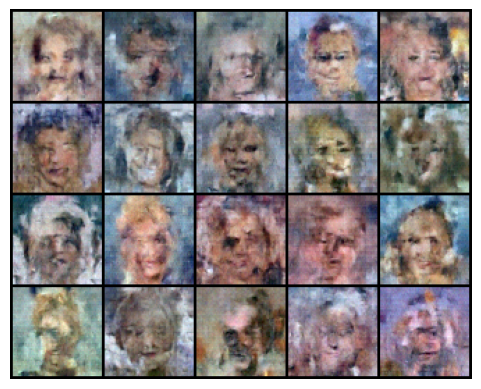

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [08:02<00:00,  6.56it/s]


Avg Loss: 0.0412483435413616
Epoch: 2
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 207.63987731933594


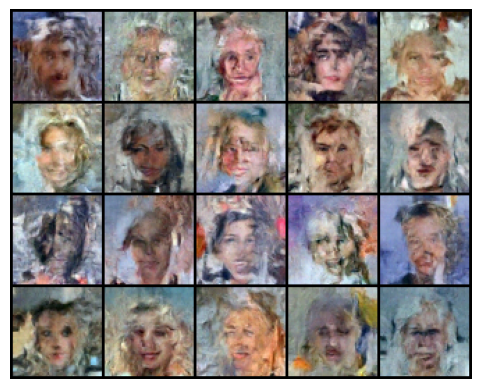

 31%|███████████████████████████████████████████████████████                                                                                                                         | 991/3166 [02:23<05:14,  6.91it/s]


KeyboardInterrupt: 

In [13]:
d = DiffusionCelebA()
d.train()

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
Resumed from epoch 2


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [14:28<00:00,  3.65it/s]


Avg Loss: 0.03889008979557231


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:45<00:00,  7.81it/s]


Avg Loss: 0.037552587488526155


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:17<00:00,  8.39it/s]


Avg Loss: 0.03680178786987416
Epoch: 5
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 149.0355682373047


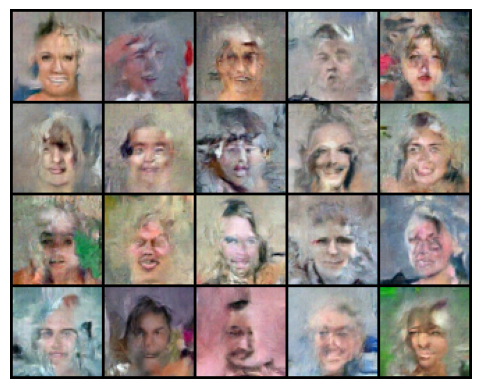

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:41<00:00,  7.89it/s]


Avg Loss: 0.03611114834431166


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:15<00:00,  8.43it/s]


Avg Loss: 0.035489479241632656


  1%|█▉                                                                                                                                                                               | 35/3166 [00:04<06:39,  7.84it/s]


KeyboardInterrupt: 

In [ ]:
d = DiffusionCelebA()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint_CelebA.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
Resumed from epoch 7


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [09:34<00:00,  5.51it/s]


Avg Loss: 0.03546622949131704


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:50<00:00,  7.71it/s]


Avg Loss: 0.03503716280754474


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [09:44<00:00,  5.41it/s]


Avg Loss: 0.034818039949929235
Epoch: 10
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 149.5046844482422


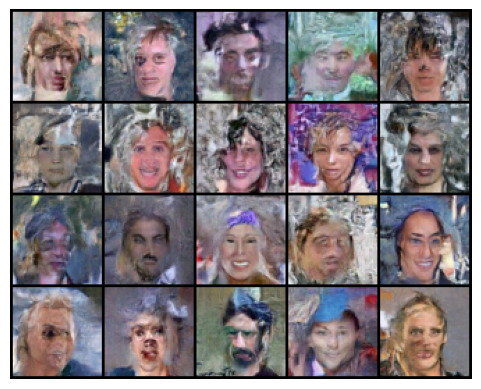

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [06:59<00:00,  7.54it/s]


Avg Loss: 0.03460931590218767


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [07:16<00:00,  7.26it/s]


Avg Loss: 0.034402398657305516


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [07:10<00:00,  7.36it/s]


Avg Loss: 0.03441256952642058


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [07:26<00:00,  7.09it/s]


Avg Loss: 0.03395907587147614


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3166/3166 [19:47<00:00,  2.67it/s]


Avg Loss: 0.03403233580670154
Epoch: 15
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1024 samples).
FID: 129.60313415527344


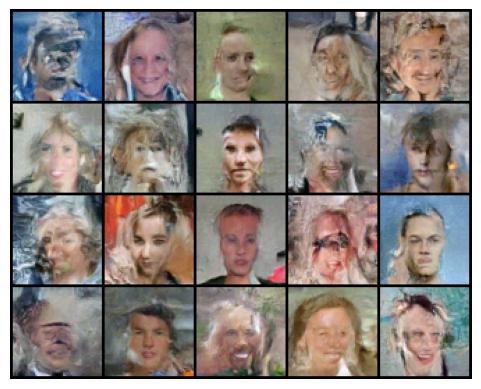

Final Epoch:


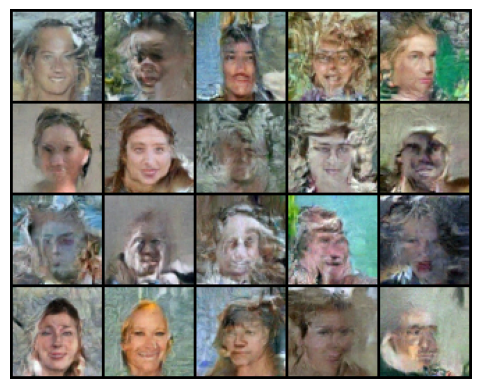

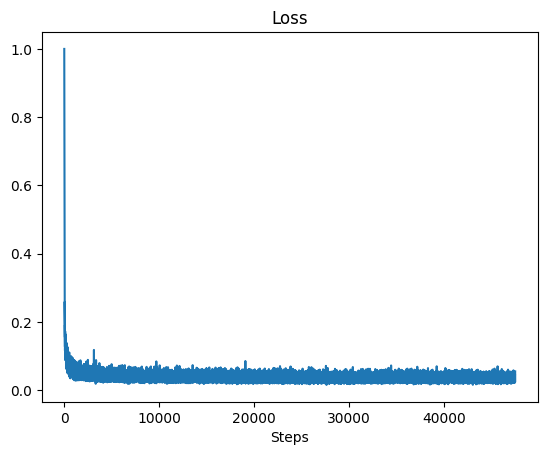

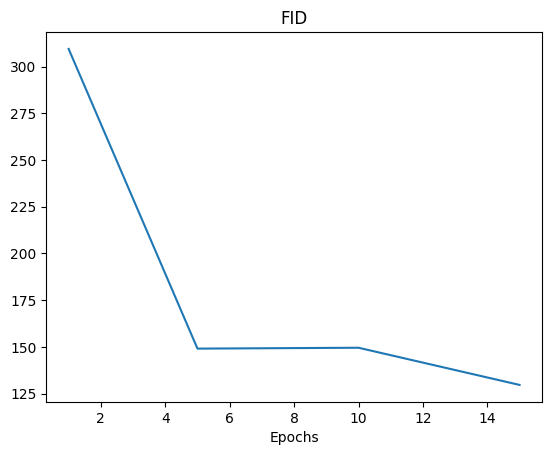

In [9]:
d = DiffusionCelebA()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint_CelebA.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)

## Extra Credit: Flow Matching
Implement Flow Matching. For flow matching, you must use a different time embedding — luckily we have given this to you for free in DiT.py as a continuous time embedding. For full credit, you must reach an FID < 100. You must also complete the inference in 100 steps.

In [6]:
### Set Hyperparameters, do not change these, unless you are doing extra credit
res = 28
patch_size = 4
channels = 1
heads = 8
hidden_dim = 256
num_patch = (res // patch_size) ** 2
ff_dim = 1024
time_emb_dim = 256
num_blocks = 5
num_timesteps = 300

beta_0 = 0.0001
beta_t = 0.02

batch_size = 64
num_epoch = 100
lr=4e-4

flow_steps = 100

In [7]:
class FlowMatching:

    def __init__(self):

        trans = transforms.Compose([
            transforms.Resize(res),
            transforms.ToTensor(),
            transforms.Normalize((0.5), (0.5)),
        ])
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.fid = FrechetInceptionDistance(feature=2048, normalize=True).to(self.device)
        self.num_fid_samples = 1000

        ### TODO: Initialize the dataset, use the MNIST dataset with the transform
        self.dataset = datasets.MNIST(root='./data', train=True, download=True, transform=trans)
        self.training_dataloader = DataLoader(self.dataset, batch_size=batch_size, shuffle=True)


        ### TODO: Follow the instructions in the website,
        ## Create a linear schedule for the betas
        # Alpha bar (cumulative product)

        ####### No betas/alphas schedule needed for flow matching ######
        


        ### TODO: Initialize the model with the correct parameters, set model to use CUDA
        self.model = DiT(
            patch_size=patch_size,
            num_blocks=num_blocks,
            num_heads=heads,
            ff_dim=ff_dim,
            time_emb_dim=time_emb_dim,
            num_timesteps=num_timesteps,
            hidden_dim=hidden_dim,
            num_patches=num_patch,
            num_channels=channels,
            training_type="flow_matching"
        ).to(self.device)


        ### TODO: Initialize the optimizer, use AdamW with the correct learning rate
        self.optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr)

        ### TODO: Initialize the loss function, use MSE loss
        self.loss_fn = torch.nn.MSELoss()

        os.makedirs('checkpoints', exist_ok=True)
        self._precompute_fid_real()


    def load_checkpoint(self, path='checkpoints/checkpoint_FlowMatching.pt'):
        checkpoint = torch.load(path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])
        print(f"Resumed from epoch {checkpoint['epoch'] + 1}")
        return (
            checkpoint['epoch'] + 1,
            checkpoint.get('total_losses', []),
            checkpoint.get('all_fids', []),
            checkpoint.get('fid_epochs', []),
        )


    def train(self, start_epoch=0, total_losses=None, all_fids=None, fid_epochs=None):
        total_losses = total_losses or []
        all_fids = all_fids or []
        fid_epochs = fid_epochs or []
        for e in range(start_epoch, num_epoch):
            self.model.train()

            all_losses = []

            for imgs, _ in tqdm(self.training_dataloader):
                # get clean image x0
                x0 = imgs.to(self.device) # (batch_size, channels, res, res)

                # t ~ Uniform(0, 1), continuous
                t = torch.rand((imgs.shape[0],), device=self.device)

                # sample random gaussian noise
                noise = torch.randn_like(x0)

                # interpolated image xt
                t_view = t.view(-1, 1, 1, 1)  # (64,) -> (64, 1, 1, 1)
                xt = (1 - t_view) * x0 + t_view * noise
                
                # compute target velocity
                v_target = noise - x0

                # predict velocity using DiT
                v_pred = self.model(xt, t)

                # Compute the loss and append it to all_losses
                loss = self.loss_fn(v_pred, v_target)
                all_losses.append(loss.item())

                # Backpropagate the loss
                self.optimizer.zero_grad()
                loss.backward()

                ## Update the model parameters
                self.optimizer.step()

            print("Avg Loss:", sum(all_losses) / len(all_losses))
            total_losses += all_losses
            all_losses = []

            # Save checkpoint after every epoch
            torch.save({
                'epoch': e,
                'model': self.model.state_dict(),
                'optimizer': self.optimizer.state_dict(),
                'total_losses': total_losses,
                'all_fids': all_fids,
                'fid_epochs': fid_epochs,
            }, 'checkpoints/checkpoint_FlowMatching.pt')

            if e + 1 in {1, 21, 51, 100}:
                print("Epoch:", e + 1)
                imgs = self.run_inference()
                fid_val = self.compute_fid()
                print("FID:", fid_val)
                all_fids.append(fid_val)
                fid_epochs.append(e + 1)
                show_images(imgs)

        print("Final Epoch:")
        final_imags = self.run_inference()
        show_images(final_imags)

        plt.plot(total_losses)
        plt.title("Loss")
        plt.xlabel("Steps")
        plt.show()

        plt.plot(fid_epochs, all_fids)
        plt.title("FID")
        plt.xlabel("Epochs")
        plt.show()


    def run_inference(self, num_samples=20):
        self.model.eval()
        with torch.no_grad():
            xt = torch.randn(num_samples, channels, res, res, device=self.device)

            dt = 1.0 / flow_steps
            for i in range(flow_steps):
                t = 1.0 - i * dt  # steps from 1.0 down to ~0.01
                t_tensor = torch.full((num_samples,), t, dtype=torch.float32, device=self.device)
                v = self.model(xt, t_tensor)
                xt = xt - dt * v

        return xt


    # Helper function to prepare the images for the FID
    def _prepare_for_fid(self, imgs_m1_1):
        """MNIST [-1,1] 28x28 -> RGB [0,1] 75x75 (shape expected by FID)."""
        imgs = (imgs_m1_1 / 2 + 0.5).clamp(0, 1)
        imgs = imgs.repeat(1, 3, 1, 1)
        imgs = F.resize(imgs, [75, 75], antialias=True)
        return imgs

    # Helper function to precompute the FID of the real data
    def _precompute_fid_real(self):
        print(
            f"[FID] Pre-computing real features on up to {self.num_fid_samples} samples...")
        total = 0
        for imgs, _ in self.dataset:
            imgs = imgs.to(self.device)
            imgs = self._prepare_for_fid(imgs)
            self.fid.update(imgs, real=True)
            total += imgs.size(0)
            if total >= self.num_fid_samples:
                break
        print(f"[FID] Real features ready ({total} samples).")

    # Helper function to compute the FID of the generated images
    @torch.no_grad()
    def compute_fid(self):
        """Generate num_fid_samples fake images, return FID float."""
        if self.fid is None:
            return None
        self.model.eval()
        batch = 200
        needed = self.num_fid_samples
        done = 0

        while done < needed:
            n = min(batch, needed - done)
            fake = self.run_inference(num_samples=n)
            fake = self._prepare_for_fid(fake.to(self.device))
            self.fid.update(fake, real=False)
            done += n

        # Move to CPU for compute() since torch.linalg.eigvals requires MAGMA on GPU
        self.fid.cpu()
        val = float(self.fid.compute().item())
        self.fid.to(self.device)

        self.fid.reset()
        self._precompute_fid_real()
        self.model.train()
        return val

[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:04<00:00, 14.61it/s]


Avg Loss: 0.4178068471361579
Epoch: 1
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 208.1044921875


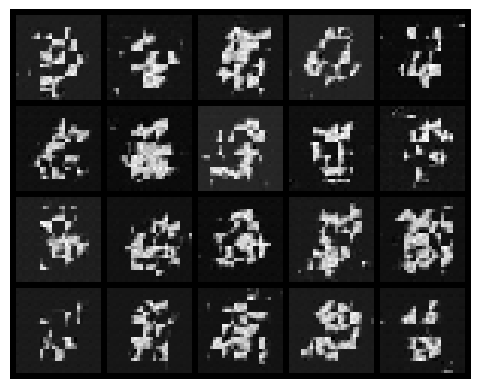

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.98it/s]


Avg Loss: 0.28433918203118


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.86it/s]


Avg Loss: 0.25490858629822477


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.00it/s]


...

Avg Loss: 0.1858509394373975


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.97it/s]


Avg Loss: 0.18386552667122152


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 14.89it/s]


Avg Loss: 0.18395430604214352
Epoch: 21
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 56.303558349609375


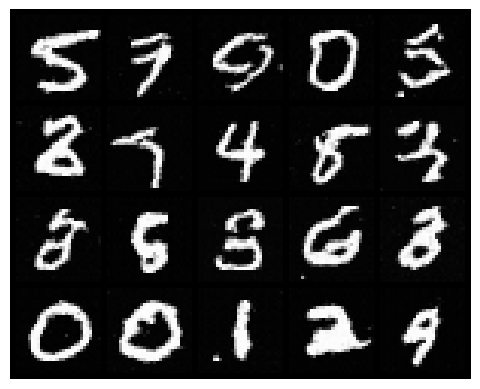

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.82it/s]


Avg Loss: 0.1844248882393593


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.01it/s]


Avg Loss: 0.1834650442226609


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.03it/s]


...

Avg Loss: 0.17614323158126904


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.74it/s]


Avg Loss: 0.17594831865797164


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.73it/s]


Avg Loss: 0.17652962048615473
Epoch: 51
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 28.347721099853516


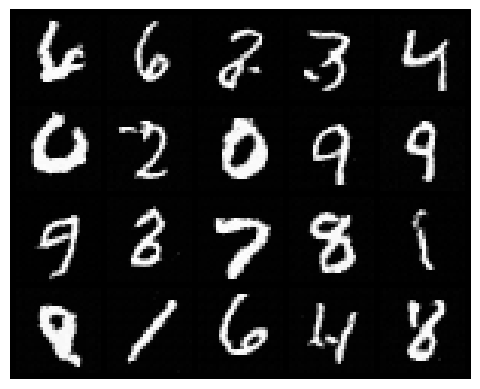

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.88it/s]


Avg Loss: 0.17562952806065077


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.89it/s]


Avg Loss: 0.17636630682548735


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:03<00:00, 14.85it/s]


...

Avg Loss: 0.17205690366944779


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:01<00:00, 15.16it/s]


Avg Loss: 0.17169626643345046


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 938/938 [01:02<00:00, 15.06it/s]


Avg Loss: 0.1721593980341832
Epoch: 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
FID: 28.46377944946289


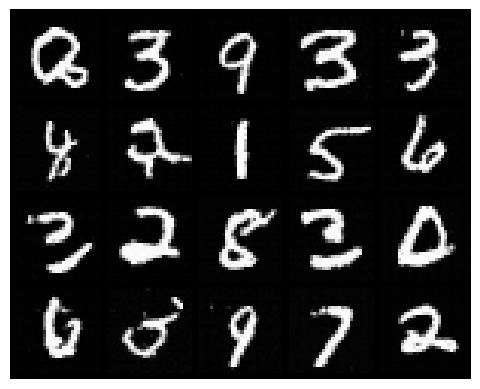

Final Epoch:


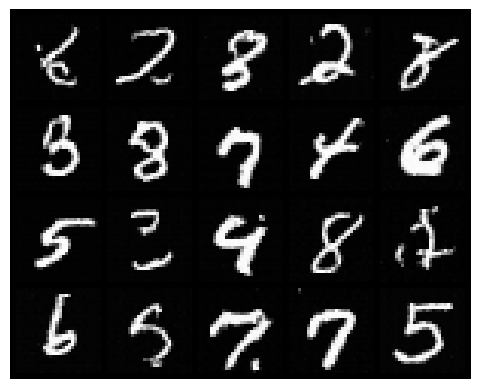

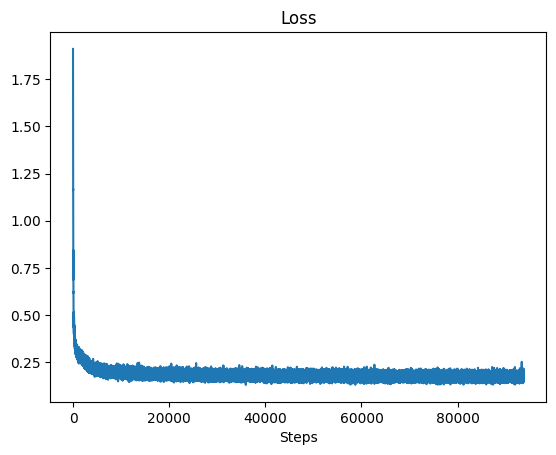

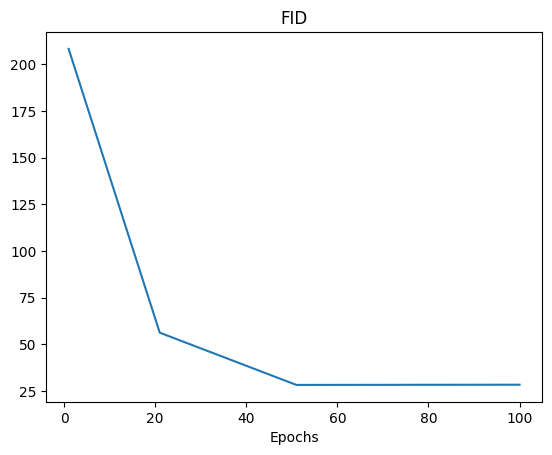

In [8]:
d = FlowMatching()
d.train()

In [ ]:
d = FlowMatching()
start_epoch, total_losses, all_fids, fid_epochs = d.load_checkpoint('checkpoints/checkpoint_FlowMatching.pt')
d.train(start_epoch=start_epoch, total_losses=total_losses, all_fids=all_fids, fid_epochs=fid_epochs)


[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
[FID] Pre-computing real features on up to 1000 samples...
[FID] Real features ready (1000 samples).
Resumed from epoch 100
DDPM 300 steps: 4.59s
DDIM 50 steps:  0.78s
Flow Matching 100 steps: 1.50s


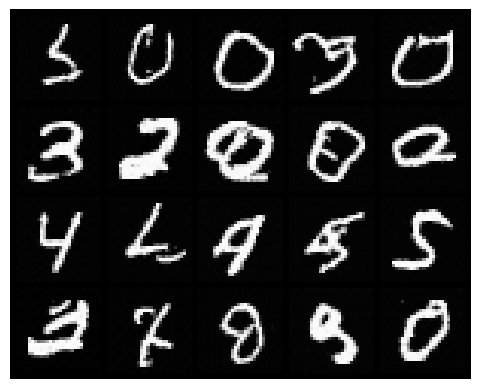

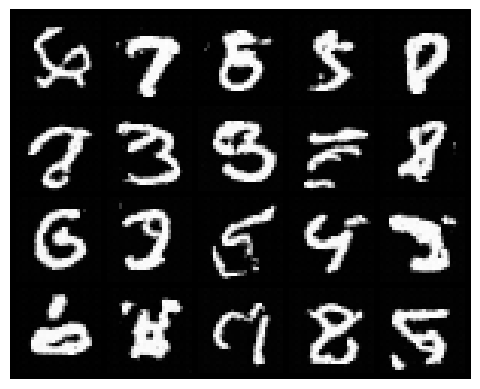

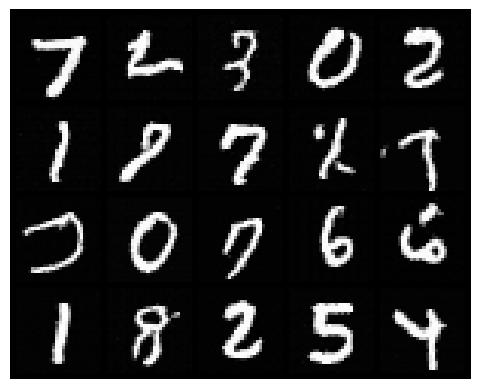

In [13]:
import time

# DDIM model (300-step schedule, 50-step inference)
ddim = DiffusionDDIM()
ddim.load_checkpoint('checkpoints/checkpoint_DDIM.pt')

# DDPM model (300-step schedule, 300-step inference)
d = Diffusion()
d.load_checkpoint('checkpoints/checkpoint.pt')

# Flow Matching model (100-step inference)
fm = FlowMatching()
fm.load_checkpoint('checkpoints/checkpoint_FlowMatching.pt')

start = time.time()
imgs_ddpm = d.run_inference(num_samples=20)
print(f"DDPM 300 steps: {time.time() - start:.2f}s")

start = time.time()
imgs_ddim = ddim.run_inference_ddim(num_samples=20, ddim_steps=50)
print(f"DDIM 50 steps:  {time.time() - start:.2f}s")

start = time.time()
imgs_fm = fm.run_inference(num_samples=20)
print(f"Flow Matching 100 steps: {time.time() - start:.2f}s")

show_images(imgs_ddpm)
show_images(imgs_ddim)
show_images(imgs_fm)